![QuantConnect Logo](https://cdn.quantconnect.com/web/i/icon.png)
<hr>

In [1]:
from AlgorithmImports import *

In [2]:
# QuantBook Analysis Tool 
# For more information see [https://www.quantconnect.com/docs/v2/our-platform/research/getting-started]
qb = QuantBook()
br = qb.set_brokerage_model(BrokerageName.COINBASE, AccountType.CASH)
sy = qb.add_crypto("BTCUSD", Resolution.MINUTE)
# Locally Lean installs free sample data, to download more data please visit https://www.quantconnect.com/docs/v2/lean-cli/datasets/downloading-data 
qb.set_start_date(2026, 1, 31)

In [3]:
sy.symbol

In [4]:
from datetime import datetime

In [5]:
df = qb.history(TradeBar, sy.symbol, datetime(2015, 6, 1), datetime(2026, 1, 31))

In [6]:
len(df)

5611740

In [7]:
df = df.reset_index()
df

,symbol,time,close,high,low,open,volume
0,BTCUSD,2015-06-01 04:01:00,230.79,230.79,230.79,230.79,0.066600
1,BTCUSD,2015-06-01 04:02:00,230.71,230.79,230.62,230.79,6.240000
2,BTCUSD,2015-06-01 04:03:00,230.75,230.75,230.71,230.71,1.891000
3,BTCUSD,2015-06-01 04:04:00,230.79,230.80,230.75,230.75,1.227300
4,BTCUSD,2015-06-01 04:05:00,230.79,230.80,230.75,230.75,0.000000
...,...,...,...,...,...,...,...
5611735,BTCUSD,2026-01-31 04:56:00,83839.99,83839.99,83791.99,83792.93,1.997224
5611736,BTCUSD,2026-01-31 04:57:00,83831.97,83856.99,83824.37,83839.99,7.318679
5611737,BTCUSD,2026-01-31 04:58:00,83823.00,83832.00,83822.38,83831.97,1.099512
5611738,BTCUSD,2026-01-31 04:59:00,83819.96,83823.00,83812.25,83823.00,0.944709


In [8]:
import pandas as pd

def analyze_time_gaps(df, time_col='time', expected_freq='1min'):
    """
    Analyzes a DataFrame for missing time gaps based on an expected frequency.
    """
    # 1. Ensure the column is datetime type and sorted chronologically
    df_sorted = df.copy()
    df_sorted[time_col] = pd.to_datetime(df_sorted[time_col])
    df_sorted = df_sorted.sort_values(by=time_col).reset_index(drop=True)
    
    # 2. Calculate the difference between consecutive timestamps
    time_diffs = df_sorted[time_col].diff()
    
    # 3. Identify where the difference is strictly greater than the expected 1 minute
    expected_delta = pd.Timedelta(expected_freq)
    gap_mask = time_diffs > expected_delta
    
    # If no gaps are found, return an empty DataFrame
    if not gap_mask.any():
        print("No gaps found!")
        return pd.DataFrame()
    
    # 4. Extract gap details
    # The gap "ends" at the row where the condition is True
    gap_ends = df_sorted.loc[gap_mask, time_col].reset_index(drop=True)
    
    # The gap "starts" at the row immediately before it
    gap_start_indices = df_sorted[gap_mask].index - 1
    gap_starts = df_sorted.loc[gap_start_indices, time_col].reset_index(drop=True)
    
    # The duration is the calculated time difference
    durations = time_diffs[gap_mask].reset_index(drop=True)
    
    # 5. Compile into a neat summary DataFrame
    gaps_summary = pd.DataFrame({
        'gap_start_time': gap_starts,
        'gap_end_time': gap_ends,
        'missing_duration': durations,
        'missing_minutes': (durations.dt.total_seconds() / 60) - 1 # Subtract 1 because a 2-min diff = 1 missing minute
    })
    
    print(f"Total gaps found: {len(gaps_summary)}")
    return gaps_summary

# ==========================================
# Example Usage:
# ==========================================

# Run the analysis
gaps_df = analyze_time_gaps(df, time_col='time')
print(gaps_df)

No gaps found!
Empty DataFrame
Columns: []
Index: []


In [36]:
len(df) / 60 / 24

3897.0416666666665

In [37]:
datetime(2026, 1, 5) - datetime(2017, 1, 1)  

datetime.timedelta(days=3291)

In [38]:
df.time.min(), df.time.max()

(Timestamp('2015-06-01 04:01:00'), Timestamp('2026-01-31 05:00:00'))

<Axes: xlabel='time'>

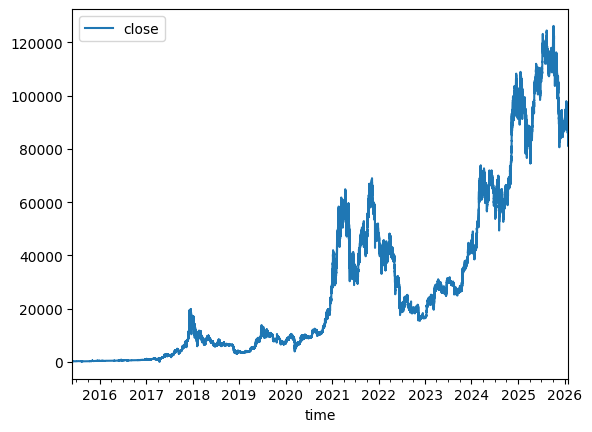

In [39]:
df.plot(x="time", y="close")

In [40]:
df.close

0            230.79
1            230.71
2            230.75
3            230.79
4            230.79
             ...   
5611735    83839.99
5611736    83831.97
5611737    83823.00
5611738    83819.96
5611739    83831.98
Name: close, Length: 5611740, dtype: float64

<Axes: xlabel='time'>

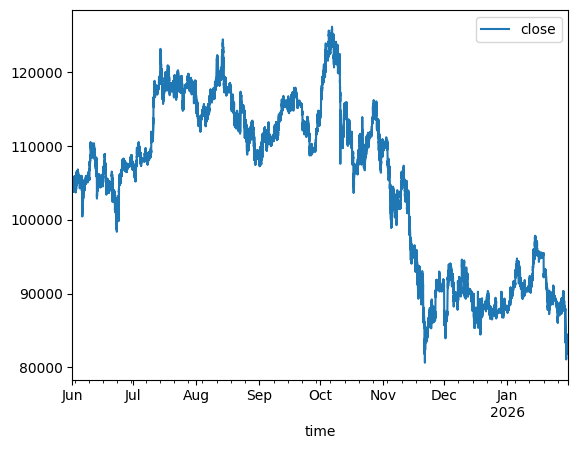

In [41]:
df[df.time >= "2025-06-01"].plot(x="time", y="close")